In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Dummy dataset (replace with your own)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0

# Simple model
def get_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    return model


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
initial_lr = 0.01
drop_factor = 0.5
epochs_drop = 5

def step_decay(epoch, lr):
    return initial_lr * (drop_factor ** (epoch // epochs_drop))

lr_scheduler = keras.callbacks.LearningRateScheduler(step_decay, verbose=1)

model = get_model()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=initial_lr),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    callbacks=[lr_scheduler],
    validation_data=(x_test, y_test)
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 1: LearningRateScheduler setting learning rate to 0.01.
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8829 - loss: 0.3729 - val_accuracy: 0.9628 - val_loss: 0.1191 - learning_rate: 0.0100

Epoch 2: LearningRateScheduler setting learning rate to 0.01.
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9663 - loss: 0.1080 - val_accuracy: 0.9672 - val_loss: 0.1085 - learning_rate: 0.0100

Epoch 3: LearningRateScheduler setting learning rate to 0.01.
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9743 - loss: 0.0839 - val_accuracy: 0.9676 - val_loss: 0.1161 - learning_rate: 0.0100

Epoch 4: LearningRateScheduler setting learning rate to 0.01.
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9775 - loss: 0.0691 - val_accuracy: 0.9707 - val_loss: 0.1157 - learning_rate: 0.0100

Epoch 5: LearningRateScheduler setting learning rate to 0.01.
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9810 - loss

In [3]:
initial_lr = 0.01

lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_lr,
    decay_steps=1000,
    decay_rate=0.9,
    staircase=False  # True = step-like, False = smooth
)

optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)

model = get_model()
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_test, y_test)
)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8890 - loss: 0.3613 - val_accuracy: 0.9633 - val_loss: 0.1244
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9672 - loss: 0.1049 - val_accuracy: 0.9683 - val_loss: 0.1080
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9749 - loss: 0.0797 - val_accuracy: 0.9707 - val_loss: 0.1097
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9792 - loss: 0.0652 - val_accuracy: 0.9705 - val_loss: 0.1084
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9846 - loss: 0.0488 - val_accuracy: 0.9698 - val_loss: 0.1138
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9850 - loss: 0.0469 - val_accuracy: 0.9740 - val_loss: 0.1060
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9887 - loss: 0.0339 - val_accuracy: 0.9743 - val_loss: 0.1066
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9907 - loss: 0.0296 - val_accuracy: 0.

In [4]:
optimizer = keras.optimizers.Adam(learning_rate=0.01)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

model = get_model()
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    callbacks=[reduce_lr],
    validation_data=(x_test, y_test)
)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8906 - loss: 0.3535 - val_accuracy: 0.9611 - val_loss: 0.1284 - learning_rate: 0.0100
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9665 - loss: 0.1102 - val_accuracy: 0.9654 - val_loss: 0.1197 - learning_rate: 0.0100
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9744 - loss: 0.0850 - val_accuracy: 0.9724 - val_loss: 0.1017 - learning_rate: 0.0100
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9771 - loss: 0.0716 - val_accuracy: 0.9647 - val_loss: 0.1362 - learning_rate: 0.0100
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9785 - loss: 0.0673 - val_accuracy: 0.9724 - val_loss: 0.1098 - learning_rate: 0.0100
Epoch 6/20
460/469 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9816 - loss: 0.0582
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9816 - loss: 0.0584 - va

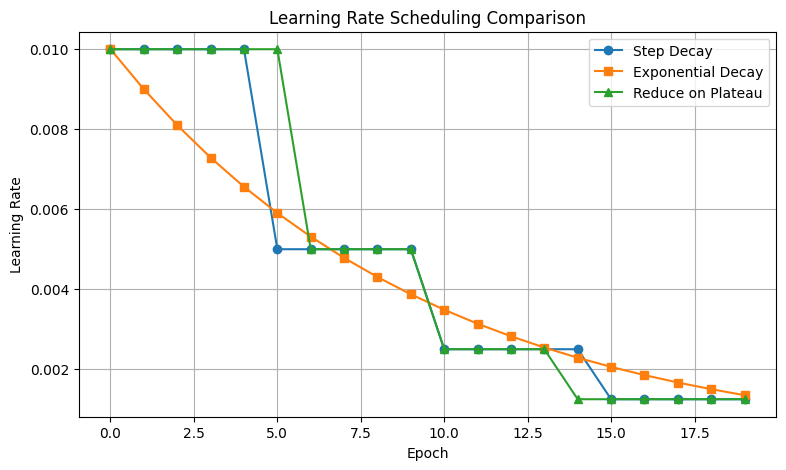

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Settings
epochs = 20
steps_per_epoch = 100
initial_lr = 0.01

# -----------------------------
# 1️⃣ Step Decay
# -----------------------------
drop_factor = 0.5
epochs_drop = 5

step_lrs = [
    initial_lr * (drop_factor ** (epoch // epochs_drop))
    for epoch in range(epochs)
]

# -----------------------------
# 2️⃣ Exponential Decay
# -----------------------------
exp_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_lr,
    decay_steps=steps_per_epoch,
    decay_rate=0.9,
    staircase=False
)

exp_lrs = [
    exp_schedule(epoch * steps_per_epoch).numpy()
    for epoch in range(epochs)
]

# -----------------------------
# 3️⃣ ReduceLROnPlateau (simulated)
# -----------------------------
# (Real version depends on val_loss, so we simulate drops)
plateau_lrs = []
lr = initial_lr
for epoch in range(epochs):
    if epoch in [6, 10, 14]:  # pretend plateau happened
        lr *= 0.5
    plateau_lrs.append(lr)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(9, 5))
plt.plot(step_lrs, marker='o', label="Step Decay")
plt.plot(exp_lrs, marker='s', label="Exponential Decay")
plt.plot(plateau_lrs, marker='^', label="Reduce on Plateau")

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Scheduling Comparison")
plt.legend()
plt.grid(True)
plt.show()
